In [17]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization as vis
from datetime import datetime
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils.model_utils import open_best_model, get_best_model_name, save_optimized_model
from constants import (
    X_train, X_train_scaled,
    y_train, y_train_scaled
)
from IPython.display import Audio, display
import winsound
import time
import numpy as np

In [18]:
def notify_optimization_complete(duration_ms=1000*60):
    """Notifica que la optimización ha terminado usando diferentes métodos."""
    # Método 1: Sonido de Windows (beep)
    try:
        winsound.Beep(440, duration_ms)  # 440Hz durante 1 segundo
    except:
        # Si falla el beep de Windows, intentar otros métodos
        try:
            # Método 2: Reproducir un tono usando IPython
            frequency = 440  # La nota A4
            t = np.linspace(0, 1, 44100)
            tone = np.sin(2*np.pi*frequency*t)
            display(Audio(tone, rate=44100, autoplay=True))
        except:
            # Método 3: Print con caracteres especiales como último recurso
            print("\n" + "="*50)
            print("🔔 ¡OPTIMIZACIÓN COMPLETADA! 🔔")
            print("="*50 + "\n")

In [19]:
def is_scaled_model(model_name: str) -> bool:
    """Determine if the model uses scaled data based on its name."""
    scaled_models = ['rf4', 'rf5', 'rf6', 'lr2']
    return any(name in model_name for name in scaled_models)

In [20]:
def print_progress_callback(study, trial):
    """Callback para mostrar progreso detallado."""
    elapsed_time = datetime.now() - study.user_attrs["start_time"]
    completed_trials = len(study.get_trials(states=[optuna.trial.TrialState.COMPLETE]))
    
    if trial.number == 0:
        study.set_user_attr("first_value", trial.value)
        improvement = 0.0
    else:
        first_value = study.user_attrs.get("first_value", trial.value)
        improvement = ((trial.value - first_value) / abs(first_value) * 100)
    
    print(f"\nPrueba {trial.number}:")
    print(f"  Valor: {trial.value:.4f}")
    print(f"  Tiempo transcurrido: {elapsed_time}")
    print(f"  Pruebas completadas: {completed_trials}/{study.user_attrs['n_trials']}")
    print(f"  Mejor valor hasta ahora: {study.best_value:.4f}")
    if trial.number > 0:  # Solo mostrar mejora después de la primera prueba
        print(f"  Mejora sobre primera prueba: {improvement:.2f}%")

In [21]:
def objective_rf(trial, X, y):
    """Función objetivo optimizada para Random Forest."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 10, 13),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'n_jobs': -1,
        'random_state': 42,
        'warm_start': True
    }
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()


In [22]:
def objective_lr(trial, X, y):
    """Función objetivo optimizada para Logistic Regression."""
    params = {
        'C': trial.suggest_loguniform('C', 1e-4, 1e4),
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'solver': trial.suggest_categorical('solver', ['saga']),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2'])
    }
    
    model = LogisticRegression(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=3, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

Cargar el mejor modelo a optimizar

In [23]:
best_model = open_best_model()
print("Best model information:")
print(f"Model type: {type(best_model).__name__}")

Best model information:
Model type: RandomForestClassifier


Determinamos el tipo de datos a utilizar

In [24]:
model_name = get_best_model_name()
print("model_name", model_name)
use_scaled_data = is_scaled_model(model_name)

if use_scaled_data:
    print("Using scaled data for optimization")
    X = X_train_scaled
    y = y_train_scaled.values.ravel()
else:
    print("Using original (unscaled) data for optimization")
    X = X_train
    y = y_train.values.ravel()

model_name optimized_rf_scaled
Using original (unscaled) data for optimization


Configuramos el estudio de optimizacion

In [25]:
sampler = TPESampler(
    n_startup_trials=5,
    multivariate=True,
    seed=42
)

pruner = MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=5,
    interval_steps=1
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

[I 2025-04-29 04:11:19,763] A new study created in memory with name: no-name-67a60764-cee5-4c87-b7c4-3c4229a577e1


Configuramos los parametros

In [26]:
n_trials = 200
timeout = 1800

Congfiguramos la hora de inicio de la optimizacion

In [27]:
study.set_user_attr("start_time", datetime.now())
study.set_user_attr("n_trials", n_trials)

Seleccionamos la funcion objetivo apopiada

In [28]:
if isinstance(best_model, RandomForestClassifier):
    objective = lambda trial: objective_rf(trial, X, y)
    print("Optimizing RandomForest model")
else:
    objective = lambda trial: objective_lr(trial, X, y)
    print("Optimizing LogisticRegression model")

Optimizing RandomForest model


Ejecutamos el proceso de optimizacion

In [29]:
try:
    print("\nIniciando optimización...")
    print(f"Tiempo máximo: {timeout} segundos")
    print(f"Número máximo de pruebas: {n_trials}")
    
    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        callbacks=[print_progress_callback],
        n_jobs=-1,
        gc_after_trial=True,
        show_progress_bar=True
    )
except KeyboardInterrupt:
    print("\nOptimización interrumpida por el usuario.")
finally:
    # Notificar que el proceso ha terminado
    notify_optimization_complete()
    
    # Imprimir resultados finales
    print("\nResultados de la Optimización")
    print("=" * 50)
    print(f"Número de pruebas completadas: {len(study.trials)}")
    print(f"\nMejor prueba:")
    trial = study.best_trial
    print(f"  Valor: {trial.value:.4f}")
    print("\n  Parámetros:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    # Usar get() para evitar KeyError
    start_time = study.user_attrs.get("start_time")
    if start_time is not None:
        total_time = datetime.now() - start_time
        print(f"\nTiempo total de optimización: {total_time}")
    
    # Calcular mejora total si hay más de una prueba
    if len(study.trials) > 1:
        first_value = study.user_attrs.get("first_value")
        if first_value is not None:
            total_improvement = ((study.best_value - first_value) / abs(first_value) * 100)
            print(f"Mejora total: {total_improvement:.2f}%")


Iniciando optimización...
Tiempo máximo: 1800 segundos
Número máximo de pruebas: 1


Best trial: 0. Best value: 0.886453: 100%|██████████| 1/1 [01:16<00:00, 76.05s/it, 76.04/1800 seconds]


[I 2025-04-29 04:12:35,780] Trial 0 finished with value: 0.8864534922104685 and parameters: {'n_estimators': 277, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.8864534922104685.

Prueba 0:
  Valor: 0.8865
  Tiempo transcurrido: 0:01:16.068488
  Pruebas completadas: 1/1
  Mejor valor hasta ahora: 0.8865

Resultados de la Optimización
Número de pruebas completadas: 1

Mejor prueba:
  Valor: 0.8865

  Parámetros:
    n_estimators: 277
    max_depth: 13
    min_samples_split: 3
    min_samples_leaf: 2
    max_features: log2
    class_weight: balanced_subsample

Tiempo total de optimización: 0:02:16.086651


Creación y guardado del modelo final

In [30]:
if isinstance(best_model, RandomForestClassifier):
    optimized_model = RandomForestClassifier(**study.best_trial.params, random_state=42)
else:
    optimized_model = LogisticRegression(**study.best_trial.params, random_state=42)

# Entrenar el modelo optimizado
optimized_model.fit(X, y)

# Guardar el modelo optimizado
model_name = 'optimized_rf' if isinstance(best_model, RandomForestClassifier) else 'optimized_lr'
model_name = f"{model_name}_scaled" if use_scaled_data else model_name
save_optimized_model(optimized_model, model_name)
print(f"\nModelo optimizado guardado como: {model_name}")


Modelo optimizado guardado como: optimized_rf


### Visualización de resultados

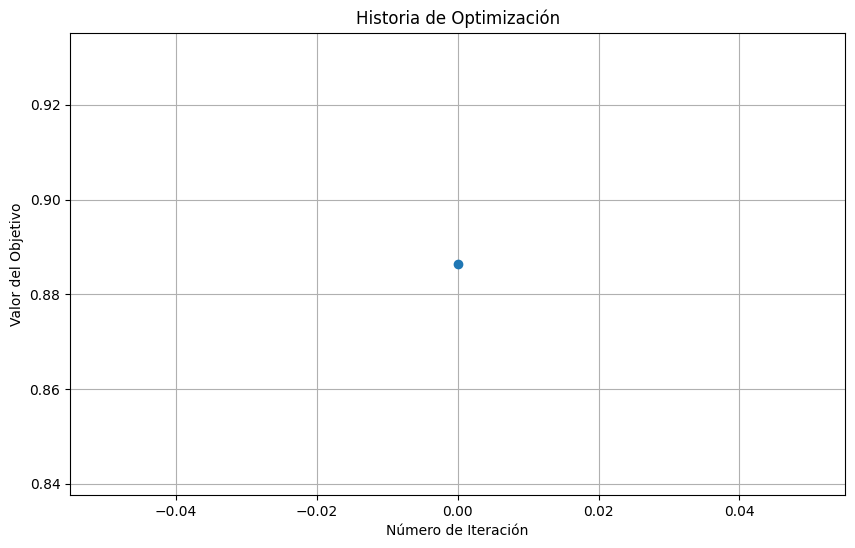

In [31]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(10, 6))
trials = study.trials
values = [t.value for t in trials if t.value is not None]
iterations = list(range(len(values)))

plt.plot(iterations, values, marker='o')
plt.xlabel('Número de Iteración')
plt.ylabel('Valor del Objetivo')
plt.title('Historia de Optimización')
plt.grid(True)
plt.show()

Grafica de la importancia de los parametros

In [32]:
if len(study.trials) > 1:
    plt.figure(figsize=(10, 6))
    importance = optuna.importance.get_param_importances(study)
    
    # Ordenar por importancia
    sorted_importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))
    
    # Crear gráfico de barras
    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()))
    plt.xlabel('Importancia')
    plt.title('Importancia de Parámetros')
    plt.tight_layout()
    plt.show()